#Backpropagation
with own gradient descent algorithm

In [24]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit as sigmoid
import math
%matplotlib inline

## Introducing the toy dataset

We've seen in lecture that a linear classifier is bound to produce errors if our data is not linearly separable. We can avoid this issue by using a more powerful classifier.

In this tutorial, we examine a classification problem for which the data is not linearly separable. We will instead implement a neural network and train it using gradient descent, computing gradients using the backpropagation algorithm.

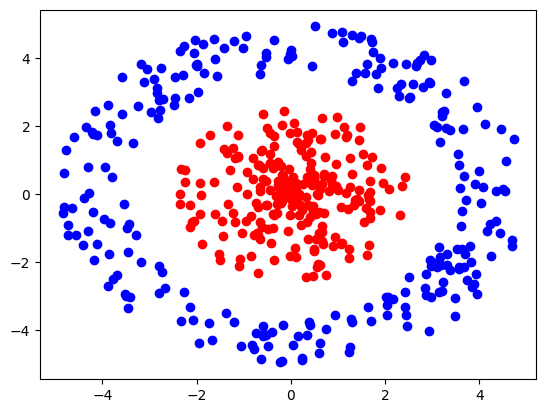

In [25]:
np.random.seed(0)

def make_dataset(num_points):
    radius = 5
    data = []
    labels = []
    # Generate positive examples (labeled 1).
    for i in range(num_points // 2):
        r = np.random.uniform(0, radius*0.5)
        angle = np.random.uniform(0, 2*math.pi)
        x = r * math.sin(angle)
        y = r * math.cos(angle)
        data.append([x, y])
        labels.append(1)

    # Generate negative examples (labeled 0).
    for i in range(num_points // 2):
        r = np.random.uniform(radius*0.7, radius)
        angle = np.random.uniform(0, 2*math.pi)
        x = r * math.sin(angle)
        y = r * math.cos(angle)
        data.append([x, y])
        labels.append(0)

    data = np.asarray(data)
    labels = np.asarray(labels)
    return data, labels

num_data = 500
data, labels = make_dataset(num_data)

# Note: red indicates a label of 1, blue indicates a label of 0
plt.scatter(data[:num_data//2, 0], data[:num_data//2, 1], color='red')
plt.scatter(data[num_data//2:, 0], data[num_data//2:, 1], color='blue')

## Neural network definition

We will try to classify this data by training a neural network. As a reminder, our goal is to take as input a two dimensional vector $\mathbf{x} = [x_1, x_2]^T$ and output $\text{Pr}(t = 1 | \mathbf{x})$, where $t$ is the label of the datapoint $\mathbf{x}$.

We will use a neural network with one hidden layer which has three hidden units. The equations describing our neural network are below:

$$\mathbf{g} = \mathbf{U} \mathbf{x} + \mathbf{b}$$
$$\mathbf{h} = \tanh(\mathbf{g})$$
$$z = \mathbf{W} \mathbf{h} + c$$
$$y = \sigma(z)$$

In the equations above, $\mathbf{U} = \begin{pmatrix} u_{11} & u_{12} \\ u_{21} & u_{22} \\  u_{31} & u_{32} \end{pmatrix} \in \mathbb{R}^{3 \times 2}, \mathbf{b} = \begin{pmatrix} b_1  \\ b_2 \\ b_3 \end{pmatrix} \in \mathbb{R}^3, \mathbf{W} = \begin{pmatrix} w_{1} & w_{2} & w_{3} \end{pmatrix} \in \mathbb{R}^{1 \times 3}, c \in \mathbb{R}$ are the parameters of our neural network which we must learn. Notice we are writing $\mathbf{W}$ as a matrix with one row.



## Vectorizing the neural network

We want our neural network to produce predictions for multiple points efficiently. We can do so by vectorizing over training examples. Let  $\mathbf{X} = \begin{pmatrix} x_{11} & x_{12} \\ \vdots   & \vdots  \\  x_{N1} & x_{N2}
\end{pmatrix}$ be a matrix containing $N$ datapoints in separate rows. Then we can vectorize by using:

$$\mathbf{G} = \mathbf{X}\mathbf{U}^T + \mathbf{1}\mathbf{b}^T$$
$$\mathbf{H} = \tanh(\mathbf{G})$$
$$\mathbf{z} =  \mathbf{H}\mathbf{W}^T + \mathbf{1}c$$
$$\mathbf{y} = \sigma(\mathbf{z})$$

$\mathbf{G}$, for example, will store each of the three hidden unit values for each datapoint in each corresponding row.

We can rewrite in scalar form as:
$$g_{ij} = u_{j1} x_{i1} + u_{j2} x_{i2} + b_j$$
$$h_{ij} = \tanh(g_{ij})$$
$$z_{i} = w_1 h_{i1} + w_2 h_{i2} + w_{3} h_{i3} + c$$
$$y_i = \sigma(z_i)$$
Here, $i$ indexes data points and $j$ indexes hidden units, so $i \in \{1, \dots, N\}$ and $j \in \{1, 2, 3\}$.


In [26]:
# First, initialize our neural network parameters.
params = {}
params['U'] = np.random.randn(3, 2)
params['b'] = np.zeros(3)
params['W'] = np.random.randn(3)
params['c'] = 0

# Notice we make use of numpy's broadcasting when adding the bias b.
def forward(X, params,tanhorLogistc=1):
    G = np.dot(X, params['U'].T)  + params['b']
    if tanhorLogistc==1:
      H = np.tanh(G)
    if tanhorLogistc==2:
      H = sigmoid(G)
    z = np.dot(H, params['W'].T) + params['c']
    y = sigmoid(z)

    return y

## Visualize the network's predictions

Let's visualize the predictions of our untrained network. As we can see, the network does not succeed at classifying the points without training

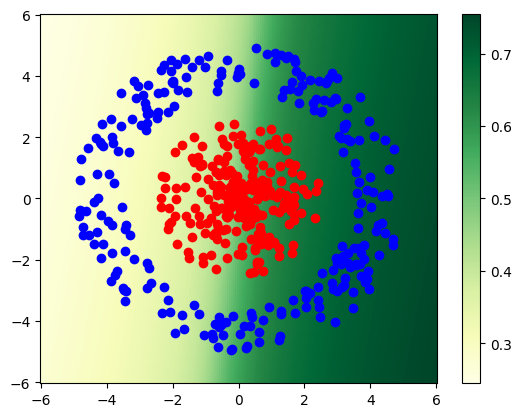

In [27]:
num_points = 200
x1s = np.linspace(-6.0, 6.0, num_points)
x2s = np.linspace(-6.0, 6.0, num_points)

points = np.transpose([np.tile(x1s, len(x2s)), np.repeat(x2s, len(x1s))])
Y = forward(points, params).reshape(num_points, num_points)
X1, X2 = np.meshgrid(x1s, x2s)

plt.pcolormesh(X1, X2, Y, cmap=plt.get_cmap('YlGn'))
plt.colorbar()
plt.scatter(data[:num_data//2, 0], data[:num_data//2, 1], color='red')
plt.scatter(data[num_data//2:, 0], data[num_data//2:, 1], color='blue')

## Loss function

We will use the same cross entropy loss function as in logistic regression. This loss function is:

$$\mathcal{L}_{CE}(y, t) = -t \log(y) - (1 - t)\log(1 - y)$$

Here $y = Pr(t = 1|\mathbf{x})$ and $t$ is the true label.

Remember that computing the derivative of this loss function $\frac{d L}{dy}$ can become numerically unstable. Instead, we combine the logistic function and the cross entropy loss into a single function called logistic cross-entropy:

$$\mathcal{L}_{LCE}(z, t) = t \log(1 + \exp(-z)) + (1 -t) \log(1 + \exp(z))$$

See Lecture 4 Notes for review on this.

Our cost function is the sum over multiple examples of the loss function, normalized by the number of examples:

$$\mathcal{E}(\mathbf{z}, \mathbf{t}) = \frac{1}{N} \left[\sum_{i=1}^N \mathcal{L}(z_i, t_i)\right]$$

## Derive backpropagation equations

We now derive the backpropagation equations in scalar form and then vectorize on the board.


In [ ]:
def PlotResult(params,data,tanhorLogistic=1):
  num_points = 200
  x1s = np.linspace(-6.0, 6.0, num_points)
  x2s = np.linspace(-6.0, 6.0, num_points)

  points = np.transpose([np.tile(x1s, len(x2s)), np.repeat(x2s, len(x1s))])
  Y = forward(points, params,tanhorLogistic).reshape(num_points, num_points)
  X1, X2 = np.meshgrid(x1s, x2s)

  plt.pcolormesh(X1, X2, Y, cmap=plt.get_cmap('YlGn'))
  plt.colorbar()
  plt.scatter(data[:num_data//2, 0], data[:num_data//2, 1], color='red')
  plt.scatter(data[num_data//2:, 0], data[num_data//2:, 1], color='blue')
  plt.show()

Text(0.5, 0, 'G')

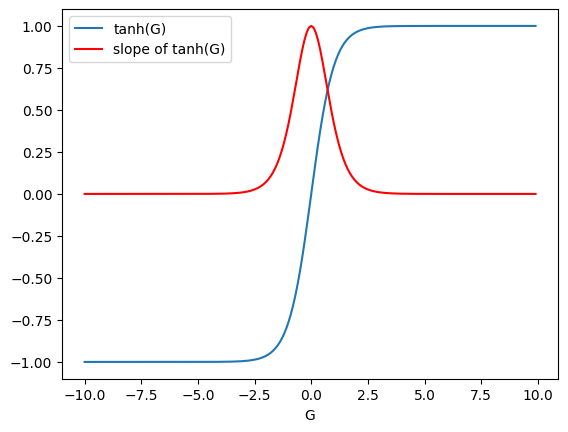

In [29]:
G = np.arange(-10,10,0.1)
plt.plot(G,np.tanh(G))
plt.plot(G, (1 - np.tanh(G)**2),color='red')
plt.legend(['tanh(G)','slope of tanh(G)'])
plt.xlabel('G')

#Part I: Code up a gradient descent algorithm using *your* expressions and confirm it works.
# Own Gadient Descent Function

In [30]:
def myGD (X,t,para,alpha=1,maxloop=100):
  N = X.shape[0]
  loss=[]
  #Forward compute
  G = np.dot(X,para['U'].T)+para['b'] #Dimensions: X=>Nx2, U=>3x2, G=>Nx3
  H = np.tanh(G)   #Dimensions: H=>Nx3
  z = np.dot(H,para['W'].T)+para['c'] #Dimensions: W=>1x3, H=>Nx3, z=>Nx1
  y = sigmoid(z)  #Dimensions: y=>Nx1

  for i in range(0,maxloop):
    #Calculate gradient
    z_bar = y-t  #Dimensions: z_bar=>Nx1
    W_bar = (1./N) *np.dot(H.T,z_bar) #Dimensions: H=>Nx3, z_bar=>Nx1, W_bar=>3x1
    c_bar = (1./N) *np.dot(z_bar, np.ones(N))
    H_bar = np.outer(z_bar, para['W'].T)
    G_bar = H_bar * (1 - np.tanh(G)**2) #Dimensions:G_bar=>Nx3
    U_bar = (1./N) * np.dot(G_bar.T, X) #Dimensions:U_bar=>3x2
    b_bar = (1./N) * np.dot(G_bar.T, np.ones(N))
    #Gradient Descent
    para['U'] -= alpha*U_bar
    para['b'] -= alpha*b_bar
    para['W'] -= alpha*W_bar
    para['c'] -= alpha*c_bar

    #Forward compute
    G = np.dot(X,para['U'].T)+para['b'] #Dimensions: X=>Nx2, U=>3x2, G=>Nx3
    H = np.tanh(G)   #Dimensions: H=>Nx3
    z = np.dot(H,para['W'].T)+para['c'] #Dimensions: W=>1x3, H=>Nx3, z=>Nx1
    y = sigmoid(z)  #Dimensions: y=>Nx1
    loss.append((1./N) * np.sum(-t * np.log(y) - (1 - t) * np.log(1 - y)))
    #if (i+1)%100==0:
      #print('At iteration ',i+1,' loss is ',loss[i])
    if i in {0,99,499,999,1999,4999}:
      print('At iteration ',i+1,' loss is ',loss[i])
      #PlotResult(para,X)
  print('Training Finished, final loss is ',loss[i])
  plt.plot(loss)
  plt.grid(True)
  return para

At iteration  1  loss is  0.8025373474420386
At iteration  100  loss is  0.2064011701383246
At iteration  500  loss is  0.048049701588215574
At iteration  1000  loss is  0.03398155294677025
At iteration  2000  loss is  0.023113107246360908
Training Finished, final loss is  0.017418738065193225
{'U': array([[-0.85932125,  0.19709308],
       [ 0.72507137,  0.89619833],
       [-0.36995233,  0.9197138 ]]), 'b': array([-1.85868884, -2.61621996,  1.96953484]), 'W': array([-8.29532592, -8.01698164,  8.16175869]), 'c': -13.379565280405966}


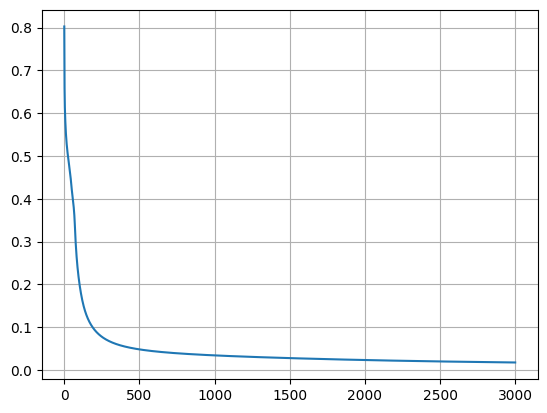

In [31]:
num_data = 500
data, labels = make_dataset(num_data)
params = {}
params['U'] = np.random.randn(3, 2)
params['b'] = np.zeros(3)
params['W'] = np.random.randn(3)
params['c'] = 0
num_steps =3000
alpha = 1
params = myGD(data,labels,params,alpha,num_steps)
print(params)

In [32]:
PlotResult(params,data,1)

AttributeError: module 'matplotlib.cm' has no attribute 'get_cmap'

# Part II: 1) Now change the nonlinearity (e.g., use the logistic function), perform the above exercises, and test it out on the dataset.

In [ ]:
def myGD_log (X,t,para,alpha=1,maxloop=100):
  N = X.shape[0]
  loss=[]
  #Forward compute
  G = np.dot(X,para['U'].T)+para['b'] #Dimensions: X=>Nx2, U=>3x2, G=>Nx3
  H = sigmoid(G)   #Dimensions: H=>Nx3
  z = np.dot(H,para['W'].T)+para['c'] #Dimensions: W=>1x3, H=>Nx3, z=>Nx1
  y = sigmoid(z)  #Dimensions: y=>Nx1

  for i in range(0,maxloop):
    #Calculate gradient
    z_bar = y-t  #Dimensions: z_bar=>Nx1
    W_bar = (1./N) *np.dot(H.T,z_bar) #Dimensions: H=>Nx3, z_bar=>Nx1, W_bar=>3x1
    c_bar = (1./N) *np.dot(z_bar, np.ones(N))
    H_bar = np.outer(z_bar, para['W'].T)
    G_bar = H_bar * (sigmoid(G)**2 * np.exp(-G)) #Dimensions:G_bar=>Nx3
    U_bar = (1./N) * np.dot(G_bar.T, X) #Dimensions:U_bar=>3x2
    b_bar = (1./N) * np.dot(G_bar.T, np.ones(N))
    #Gradient Descent
    para['U'] -= alpha*U_bar
    para['b'] -= alpha*b_bar
    para['W'] -= alpha*W_bar
    para['c'] -= alpha*c_bar

    #Forward compute
    G = np.dot(X,para['U'].T)+para['b'] #Dimensions: X=>Nx2, U=>3x2, G=>Nx3
    H = sigmoid(G)   #Dimensions: H=>Nx3
    z = np.dot(H,para['W'].T)+para['c'] #Dimensions: W=>1x3, H=>Nx3, z=>Nx1
    y = sigmoid(z)  #Dimensions: y=>Nx1
    loss.append((1./N) * np.sum(-t * np.log(y) - (1 - t) * np.log(1 - y)))
    #if (i+1)%100==0:
      #print('At iteration ',i+1,' loss is ',loss[i])
    if i in {0,99,499,999,1999,4999}:
      print('At iteration ',i+1,' loss is ',loss[i])
      #PlotResult(para,X,2)
  print('Training Finished, final loss is ',loss[i])
  plt.plot(loss)
  plt.grid(True)
  return para

('At iteration ', 1, ' loss is ', 0.7933492588751108)
('At iteration ', 100, ' loss is ', 0.5020894069635022)
('At iteration ', 500, ' loss is ', 0.08634419666501154)
('At iteration ', 1000, ' loss is ', 0.04834637628274906)
('At iteration ', 2000, ' loss is ', 0.03415655609565676)
('Training Finished, final loss is ', 0.028568281242566697)
{'c': 7.335814121914372, 'b': array([-4.94884753, -5.20314492, -5.84827403]), 'U': array([[ 1.87899435, -1.19874293],
       [-2.14216766, -1.13339453],
       [ 0.19774811,  2.69562255]]), 'W': array([-12.18645166, -12.38043113, -12.49202044])}


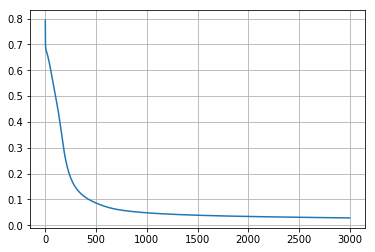

In [ ]:
num_data = 500
data, labels = make_dataset(num_data)
params = {}
params['U'] = np.random.randn(3, 2)
params['b'] = np.zeros(3)
params['W'] = np.random.randn(3)
params['c'] = 0
num_steps =3000
alpha = 1
params = myGD_log(data,labels,params,alpha,num_steps)
print(params)



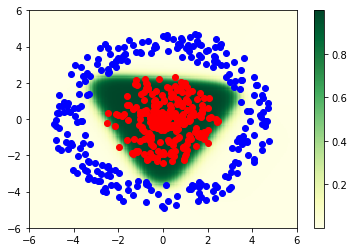

In [ ]:
PlotResult(params,data,2)

# Part II: 2. Modify the dataset to a different kind of nonlinearly separable dataset, and test out the two classifiers.

In [ ]:
# Generate nonlinear separable dataset
np.random.seed(0)
def dataset2 (num_points):
    data = []
    labels = []
    # Generate positive examples (labeled 1).
    for i in range(num_points // 2):
        x = np.random.uniform(-3,3)
        inrange = False
        while not inrange:
          y = np.random.uniform(0,6)
          if y >= (2./3 * x**2):
            inrange = True
        data.append([x, y])
        labels.append(1)

    # Generate negative examples (labeled 0).
    for i in range(num_points // 2):
       x = np.random.uniform(-6,6)
       bond1= 2./3 * x**2 - 3
       bond2= -6+1./3*x**2
       inrange = False
       while not inrange:
         y = np.random.uniform(-6,6)
         if (y < bond1) and (y > bond2):
           inrange = True
       data.append([x, y])
       labels.append(0)

    data = np.asarray(data)
    labels = np.asarray(labels)
    # Note: red indicates a label of 1, blue indicates a label of 0
    plt.scatter(data[:num_data//2, 0], data[:num_data//2, 1], color='red')
    plt.scatter(data[num_data//2:, 0], data[num_data//2:, 1], color='blue')
    return data, labels





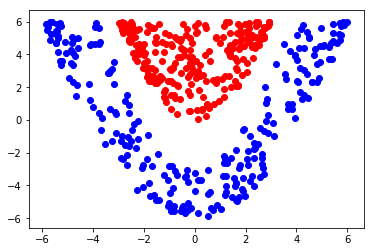

In [ ]:
# try logistic nonlinear function
num_data = 500
data, labels = dataset2(num_data)




('At iteration ', 1, ' loss is ', 0.7484868681943647)
('At iteration ', 100, ' loss is ', 0.13182082433155784)
('At iteration ', 500, ' loss is ', 0.02093481374499435)
('At iteration ', 1000, ' loss is ', 0.009243988089091701)
('At iteration ', 2000, ' loss is ', 0.004195979160292229)
('Training Finished, final loss is ', 0.002674747309173302)
{'c': 1.8292844197583478, 'b': array([-4.65860519, -3.89679612,  2.27505967]), 'U': array([[-4.12373549, -1.68151492],
       [ 3.56620625, -1.62357498],
       [-2.60836582,  1.35429646]]), 'W': array([-12.60006221,  -8.52573309,   5.05794541])}


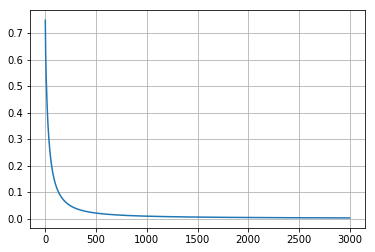

In [ ]:
params = {}
params['U'] = np.random.randn(3, 2)
params['b'] = np.zeros(3)
params['W'] = np.random.randn(3)
params['c'] = 0
num_steps =3000
alpha = 1
params = myGD_log(data,labels,params,alpha,num_steps)
print(params)

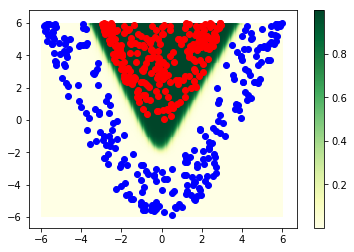

In [ ]:
PlotResult(params,data,2)

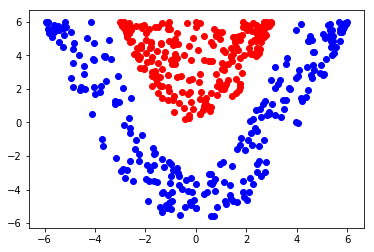

In [ ]:
# try tanh nonlinear function
num_data = 500
data, labels = dataset2(num_data)




('At iteration ', 1, ' loss is ', 0.5494509224789706)
('At iteration ', 100, ' loss is ', 0.04618387697722538)
('At iteration ', 500, ' loss is ', 0.007581685912074382)
('At iteration ', 1000, ' loss is ', 0.0035581761442250934)
('At iteration ', 2000, ' loss is ', 0.0017014167325186218)
('Training Finished, final loss is ', 0.0011123425849639194)
{'c': -6.534303400398175, 'b': array([-2.68267401, -0.01994931,  2.58395381]), 'U': array([[-2.53789067, -1.09119516],
       [-0.23784915,  2.49819011],
       [-2.27300216,  1.00760576]]), 'W': array([-7.04973363,  0.1359471 ,  7.15340811])}


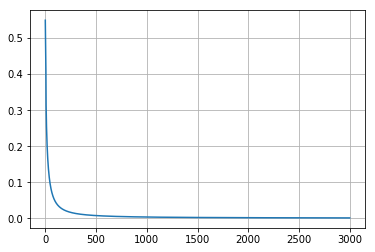

In [ ]:
params = {}
params['U'] = np.random.randn(3, 2)
params['b'] = np.zeros(3)
params['W'] = np.random.randn(3)
params['c'] = 0
num_steps =3000
alpha = 1
params = myGD(data,labels,params,alpha,num_steps)
print(params)

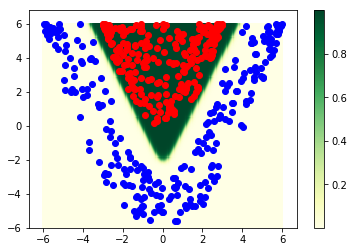

In [ ]:
PlotResult(params,data,1)

# Part II: 3. Apply your MLPs to the XOR dataset and confirm it learns the XOR dataset.

In [ ]:
def PlotXOR(params,data,tanhorLogistic=1):
  num_points = 200
  x1s = np.linspace(-1.0, 2.0, num_points)
  x2s = np.linspace(-1.0, 2.0, num_points)

  points = np.transpose([np.tile(x1s, len(x2s)), np.repeat(x2s, len(x1s))])
  Y = forward(points, params,tanhorLogistic).reshape(num_points, num_points)
  X1, X2 = np.meshgrid(x1s, x2s)

  plt.pcolormesh(X1, X2, Y, cmap=plt.get_cmap('YlGn'))
  plt.colorbar()
  plt.scatter([0,1],[0,1], color='red')
  plt.scatter([0,1],[1,0], color='blue')
  plt.show()

('At iteration ', 1, ' loss is ', 0.7080287357782578)
('At iteration ', 100, ' loss is ', 0.6778217585563567)
('At iteration ', 500, ' loss is ', 0.03863369214364991)
('Training Finished, final loss is ', 0.03863369214364991)
{'c': -3.3657305714845975, 'b': array([-2.83925139, -2.97376052,  0.25388704]), 'U': array([[-5.43385164,  5.13858716],
       [ 5.31507813, -5.57553439],
       [-0.45776848,  0.28799037]]), 'W': array([ 7.9859904 ,  7.82749309, -0.97454191])}


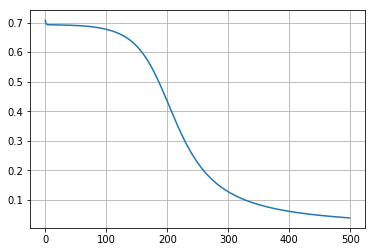

In [ ]:
# try logistic nonlinear function
x1 = [0,0,1,1]
x2 = [0,1,0,1]
data = np.array([x1,x2]).T
labels = np.array([0,1,1,0])
params = {}
params['U'] = np.random.randn(3, 2)
params['b'] = np.zeros(3)
params['W'] = np.random.randn(3)
params['c'] = 0
num_steps =500
alpha = 1
params = myGD_log(data,labels,params,alpha,num_steps)
print(params)

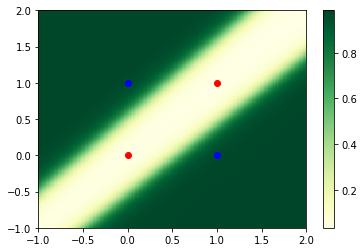

In [ ]:
PlotXOR(params,data,2)

('At iteration ', 1, ' loss is ', 0.649107974134569)
('At iteration ', 100, ' loss is ', 0.038688479776924495)
('At iteration ', 500, ' loss is ', 0.005479121738553903)
('Training Finished, final loss is ', 0.005479121738553903)
{'c': 1.2675946754896004, 'b': array([-0.8827202 ,  0.51481853, -0.55566359]), 'U': array([[ 2.5490728 , -3.73508219],
       [-2.67970399, -2.82275549],
       [-3.59617106,  2.14027228]]), 'W': array([ 5.33264502, -4.27937251,  5.33994025])}


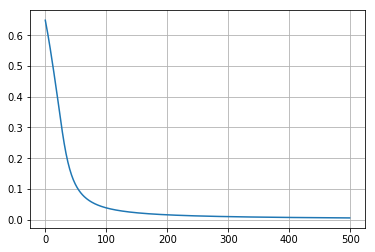

In [ ]:
# try tanh nonlinear function
x1 = [0,0,1,1]
x2 = [0,1,0,1]
data = np.array([x1,x2]).T
labels = np.array([0,1,1,0])
params = {}
params['U'] = np.random.randn(3, 2)
params['b'] = np.zeros(3)
params['W'] = np.random.randn(3)
params['c'] = 0
num_steps =500
alpha = 1
params = myGD(data,labels,params,alpha,num_steps)
print(params)

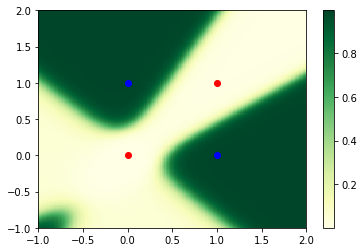

In [ ]:
PlotXOR(params,data,1)

# Part III:

# 1. What is the difference between classification and regression? Make sure you refer to the dataset and the types of data therein.

The type of target in the dataset for classification and regression are different. For classification, the predicted target is a lable while for regression, the predicted target is a numerial value. For evaluating the error, a boolean value is used to evaluate the predicted result in calssification while in regression, the error is evaluated based on numerical value of the difference between the predicted value and acutal value.    

# PartIII
# 3.Code your MLP.

In [ ]:
def nonlinearity (G):
  return np.sin(G)


In [ ]:
def MLP3Regr (X,t,para,alpha=1,maxloop=100):
  N = X.shape[0]
  loss=[]
  #Forward compute
  G = np.dot(X,para['U'].T)+para['b'] #Dimensions: X=>Nx1, U=>3x1, G=>Nx3
  H = nonlinearity (G)   #Dimensions: H=>Nx3
  y = np.dot(H,para['W'])+para['c'] #Dimensions: W=>1x3, H=>Nx3, z=>Nx1

  loss.append((1./N) * np.sum((t-y)**2))

  for i in range(0,maxloop):
    #Calculate gradient
    y_bar = 1./N* (y-t)
    W_bar = np.dot(H.T,y_bar) #Dimensions: H=>Nx3, y_bar=>Nx1, W_bar=>3x1
    c_bar = np.dot(y_bar.T, np.ones(N))
    H_bar = np.outer(y_bar, para['W'].T)
    G_bar = H_bar * (np.cos(G))  #Dimensions:G_bar=>Nx3
    U_bar = np.dot(G_bar.T, X) #Dimensions:U_bar=>3x2
    b_bar = np.dot(G_bar.T, np.ones(N))
    #Gradient Descent
    para['U'] -= alpha*U_bar
    para['b'] -= alpha*b_bar
    para['W'] -= alpha*W_bar
    para['c'] -= alpha*c_bar

    #Forward compute
    G = np.dot(X,para['U'].T)+para['b'] #Dimensions: X=>Nx2, U=>3x2, G=>Nx3
    H = nonlinearity (G)   #Dimensions: H=>Nx3
    y = np.dot(H,para['W'])+para['c'] #Dimensions: W=>1x3, H=>Nx3, z=>Nx1
    loss.append((1./N) * np.sum((t-y)**2))
    #if (i+1)%100==0:
      #print('At iteration ',i+1,' loss is ',loss[i])
    if i in {0,99,499,999,1999,4999}:
      print('At iteration ',i+1,' loss is ',loss[i])
      #PlotResult(para,X)
  print('Training Finished, final loss is ',loss[i])
  plot_regr(X,t,para)
  #plt.plot(loss)
  plt.grid(True)
  return para

In [ ]:
def plot_regr (X,t,para):
  G = np.dot(X,para['U'].T)+para['b'] #Dimensions: X=>Nx1, U=>3x1, G=>Nx3
  H = nonlinearity (G) #Dimensions: H=>Nx3
  y = np.dot(H,para['W'])+para['c'] #Dimensions: W=>1x3, H=>Nx3, z=>Nx1
  plt.scatter(X,y,color='red')
  plt.scatter(X,t,color='blue')

# Part III
# 4. Create a linear dataset (for regression) and confirm your MLP for regression can learn this dataset.

(array([0.70634832]), array([0.17573564]))


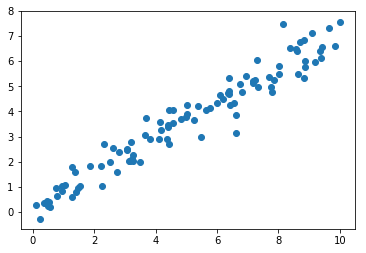

In [ ]:
def linear_dataset(num_points):
    a = np.random.rand(1)
    b = np.random.rand(1)
    print(a,b)
    data = []
    target = []
    # Generate data point.
    for i in range(0, num_points,2):
        noise = np.random.normal(0, 0.5, size=1)
        x = np.random.rand(1)*10
        y = np.dot(a,x)+b+noise
        data.append(x)
        target.append(y)
    data=np.asarray(data).reshape(-1,1)
    target=np.asarray(target).reshape(-1,1)
    return data, target

num_data = 200
data, target = linear_dataset(num_data)

plt.scatter(data, target)

('At iteration ', 1, ' loss is ', 16.686590822500172)
('At iteration ', 100, ' loss is ', 3.668794444655171)
('At iteration ', 500, ' loss is ', 0.41823734443074095)
('At iteration ', 1000, ' loss is ', 0.31795025002895866)
('At iteration ', 2000, ' loss is ', 0.2812014328273024)
('At iteration ', 5000, ' loss is ', 0.29939057336377073)
('Training Finished, final loss is ', 0.30238351988407725)
{'c': array([3.34487427]), 'b': array([-2.069217]), 'U': array([[-0.25276293]]), 'W': array([[3.3061712]])}


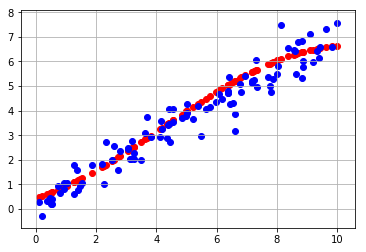

In [ ]:
params = {}
params['U'] = np.random.randn(1,1)
params['b'] = np.zeros(1)
params['W'] = np.random.randn(1,1)
params['c'] = 0
a = 0.01
params = MLP3Regr (data,target,params,alpha=a,maxloop=10000)
print(params)

# Part III
# 5. Create a polynomial dataset and confirm your MLP for regression can learn this dataset.



In [ ]:
def polynomial_dataset(num_points):
    a = np.random.rand(1)*10
    b = np.random.rand(1)*10
    c = np.random.rand(1)*10
    print(a,b,c)
    data = []
    target = []
    # Generate data point.
    for i in range(0, num_points):
        noise = np.random.normal(0, 0.8, size=1)
        x = np.random.rand(1)*1
        y = a*x**3+b*x**2+c+noise
        data.append([x])
        target.append(y)

    data=np.asarray(data).reshape(-1,1)
    target=np.asarray(target).reshape(-1,1)
    return data, target

num_data = 200
data, target = polynomial_dataset(num_data)

# Note: red indicates a label of 1, blue indicates a label of 0
plt.scatter(data, target)

('At iteration ', 1, ' loss is ', 20.446741265230777)
('At iteration ', 100, ' loss is ', 2.727246800611855)
('At iteration ', 500, ' loss is ', 0.8342207811982434)
('At iteration ', 1000, ' loss is ', 0.769072972754282)
('At iteration ', 2000, ' loss is ', 0.7361436013023416)
('At iteration ', 5000, ' loss is ', 0.715216233953881)
('Training Finished, final loss is ', 0.7066211481638487)
{'c': array([0.86156582]), 'b': array([-0.28564492,  0.29444943, -0.87553017]), 'U': array([[1.60176785],
       [1.19432563],
       [0.56113641]]), 'W': array([[ 5.06687318],
       [ 1.78044802],
       [-0.69990215]])}


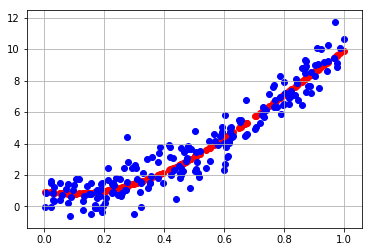

In [ ]:
params = {}
params['U'] = np.random.randn(3,1)
params['b'] = np.zeros(3)
params['W'] = np.random.randn(3,1)
params['c'] = 0
params = MLP3Regr (data,target,params,alpha=0.01,maxloop=10000)
print(params)

# Part III: 6. Try it on a different type of nonlinear dataset.

(array([1.02441904]), array([7.36765986]), array([1.37827305]))


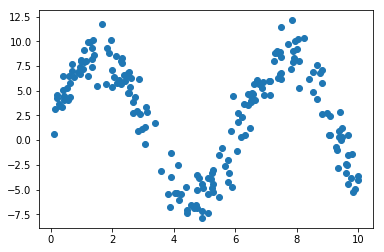

In [ ]:
def sin_dataset(num_points):
    a = np.random.rand(1)*2
    b = np.random.rand(1)*10
    c = np.random.rand(1)*5
    print(a,b,c)
    data = []
    target = []
    # Generate data point.
    for i in range(0, num_points):
        noise = np.random.normal(0, 0.2*b, size=1)
        x = np.random.rand(1)*10
        y = b*np.sin(a*x)+c+noise
        data.append([x])
        target.append(y)

    data=np.asarray(data).reshape(-1,1)
    target=np.asarray(target).reshape(-1,1)
    return data, target

num_data = 200
data, target = sin_dataset(num_data)

# Note: red indicates a label of 1, blue indicates a label of 0
plt.scatter(data, target)

('At iteration ', 1, ' loss is ', 39.5418757429382)
('At iteration ', 100, ' loss is ', 23.142971423205896)
('At iteration ', 500, ' loss is ', 17.133905868231945)
('At iteration ', 1000, ' loss is ', 8.795905692299723)
('At iteration ', 2000, ' loss is ', 4.20175852555219)
('At iteration ', 5000, ' loss is ', 3.0897088924045306)
('Training Finished, final loss is ', 2.7092733283424972)
{'c': array([0.17757536]), 'b': array([ 3.25983316,  2.39098056, -0.09177463]), 'U': array([[ 1.01725062],
       [-0.3749404 ],
       [ 0.01389859]]), 'W': array([[-0.79061708],
       [ 2.09605047],
       [ 0.36885215]])}


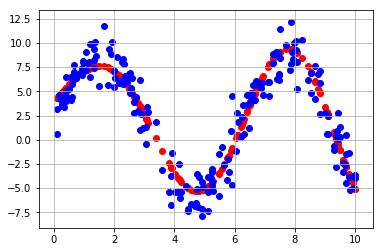

In [ ]:
params = {}
params['U'] = np.random.randn(3,1)
params['b'] = np.zeros(3)
params['W'] = np.random.randn(3,1)
params['c'] = 0
params = MLP3Regr (data,target,params,alpha=0.001,maxloop=10000)
print(params)

## Looking forward: Automatic differentiation

You probably noticed that manually deriving the backpropagation equations is slow and error prone. It becomes even easier to make an error when implementing in code. Luckily, we almost never have to derive the backwards equations by hand. Instead, we make use of automatic differentation software packaged in libraries such as Autograd, PyTorch, and Tensorflow to compute derivatives for us.